In [4]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset (2).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking charts

In [7]:
df = pd.read_csv("placement_predict_50k Dataset.csv", on_bad_lines='skip')

/tmp/ipykernel_1171/3996971939.py:1: DtypeWarning: Columns (16,20,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("placement_predict_50k Dataset.csv", on_bad_lines='skip')


In [8]:
print("First 5 rows of the dataset:")
display(df.head())          # use display() in Colab; use print(df.head()) elsewhere


First 5 rows of the dataset:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1.0,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0.0,66.7,2.2,49.4,47.8,0.0,Low,0.0,0.0,0.00
1,2.0,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0.0,48.2,2.4,26.7,25.8,0.0,Low,0.0,0.0,0.00
2,3.0,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0.0,73.8,2.8,67.7,41.5,0.0,Low,1.0,0.0,3.89
3,4.0,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0.0,69.8,2.7,66.9,48,0.0,Mid,1.0,0.0,8.37
4,5.0,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1.0,73.1,2.1,71.7,61.7,1.0,High,1.0,0.0,18.99


In [9]:
print("\nShape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())




Shape of dataset (rows, columns): (84554, 32)

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84554 entries, 0 to 84553
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           84554 non-null  float64
 1   Gender              84554 non-null  object 
 2   City                84554 non-null  object 
 3   CollegeTier         84554 non-null  object 
 4   Stream              

In [11]:
df['Placed_Flag'] = df['PlacementStatus'].apply(lambda x: 1 if x == 'Placed' else 0)



In [12]:
num_cols = ['CGPA', 'AttendancePercent', 'AptitudeTestScore',
            'CodingTestScore', 'SoftSkillsRating', 'Salary Package']



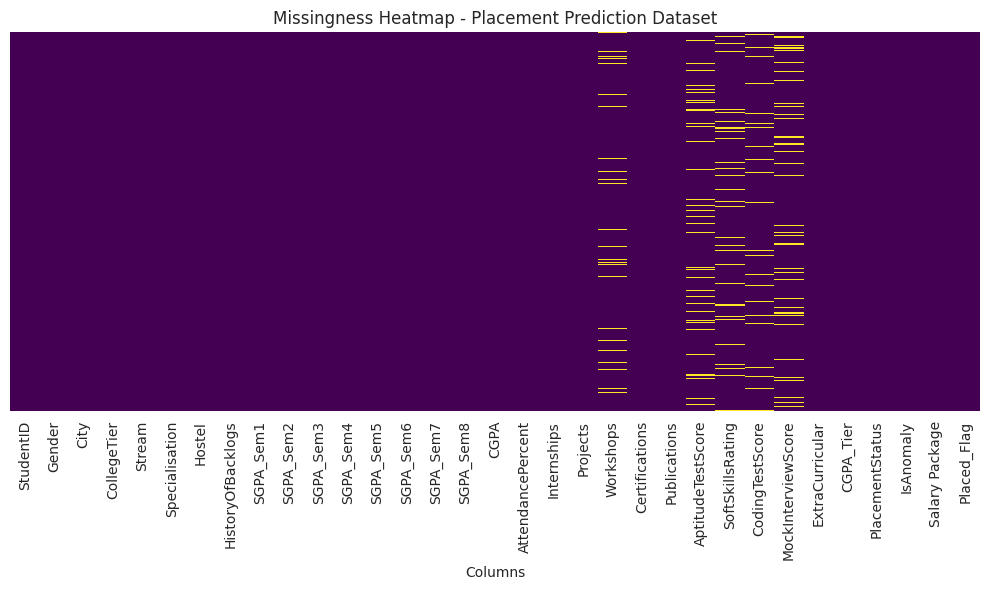

In [13]:
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


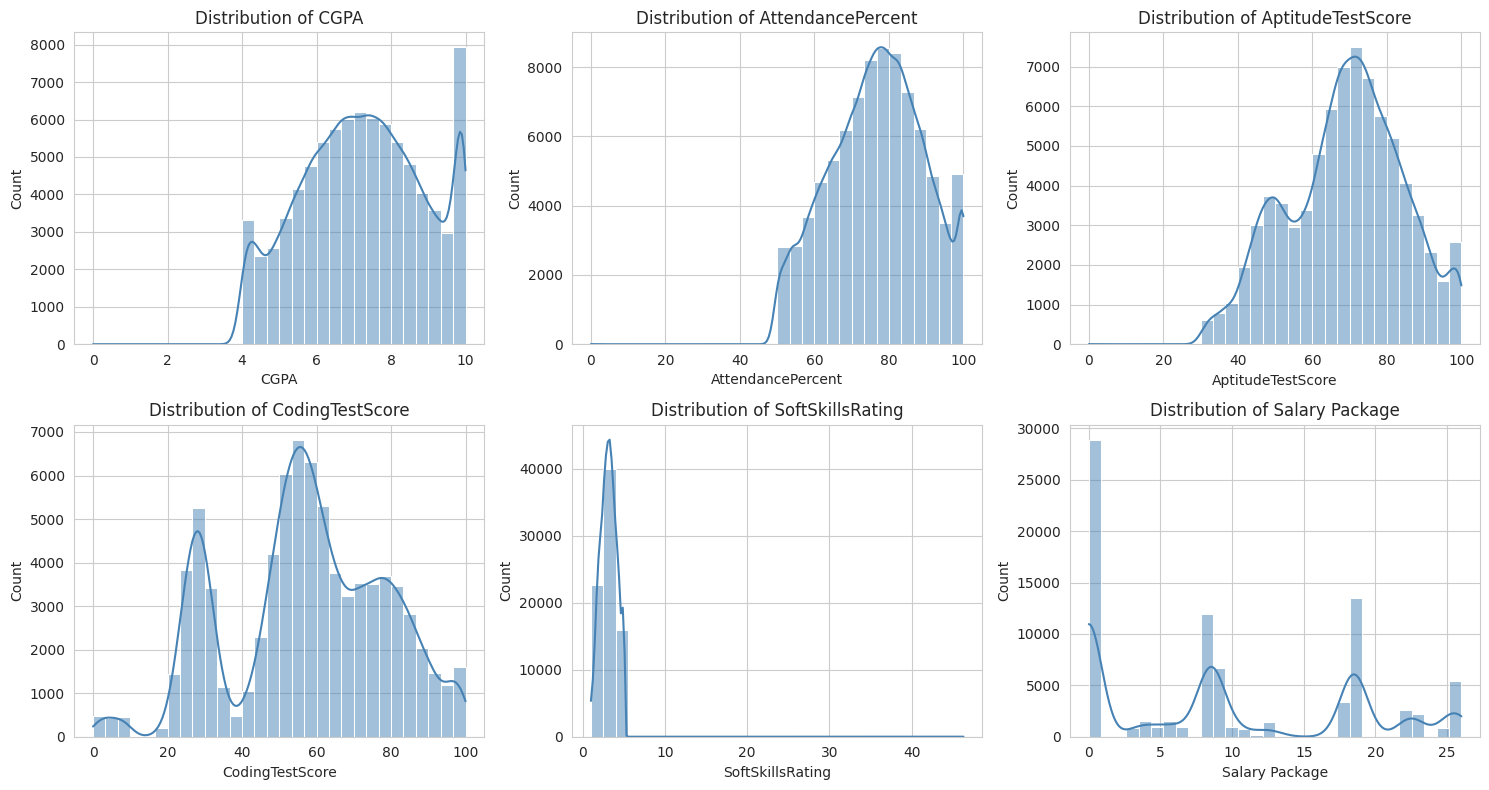

In [15]:
df['CGPA'] = pd.to_numeric(df['CGPA'], errors='coerce')
df['SoftSkillsRating'] = pd.to_numeric(df['SoftSkillsRating'], errors='coerce')

fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1171/2158546150.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')


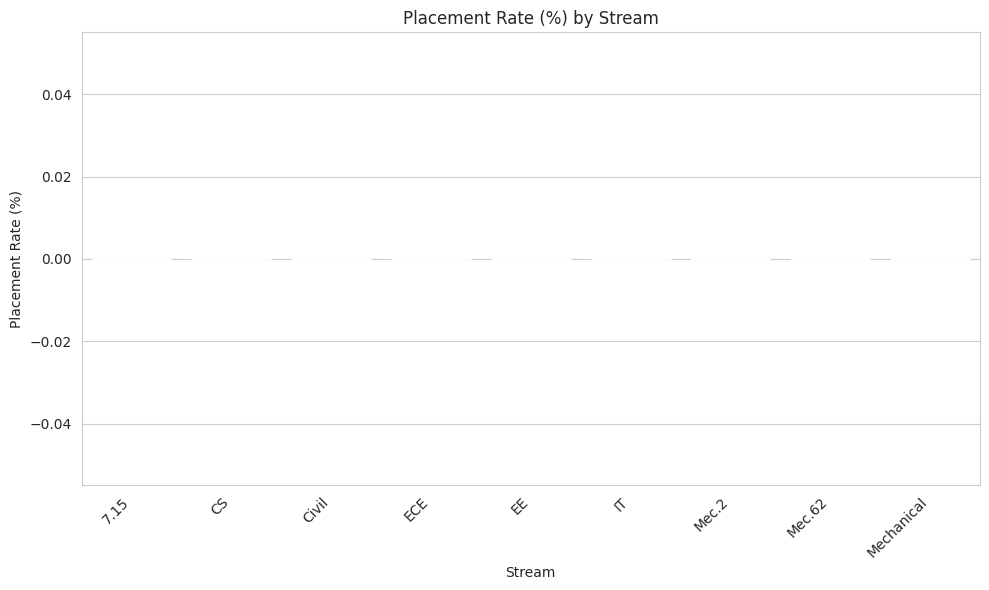


Placement rate (%) by stream:
Stream
7.15          0.0
CS            0.0
Civil         0.0
ECE           0.0
EE            0.0
IT            0.0
Mec.2         0.0
Mec.62        0.0
Mechanical    0.0
Name: Placed_Flag, dtype: float64


In [16]:
fig3 = plt.figure(figsize=(10, 6))

placement_rate = (
    df.groupby('Stream')['Placed_Flag'].mean().sort_values(ascending=False) * 100
)

sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')
plt.title('Placement Rate (%) by Stream')
plt.xlabel('Stream')
plt.ylabel('Placement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPlacement rate (%) by stream:")
print(placement_rate.round(2))


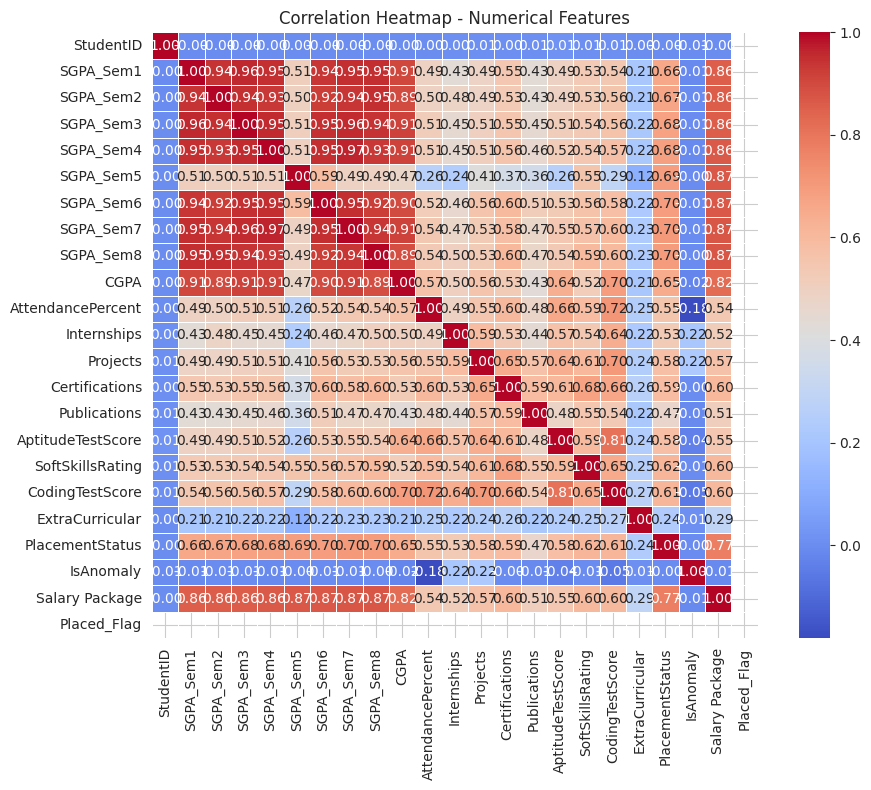

In [17]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()




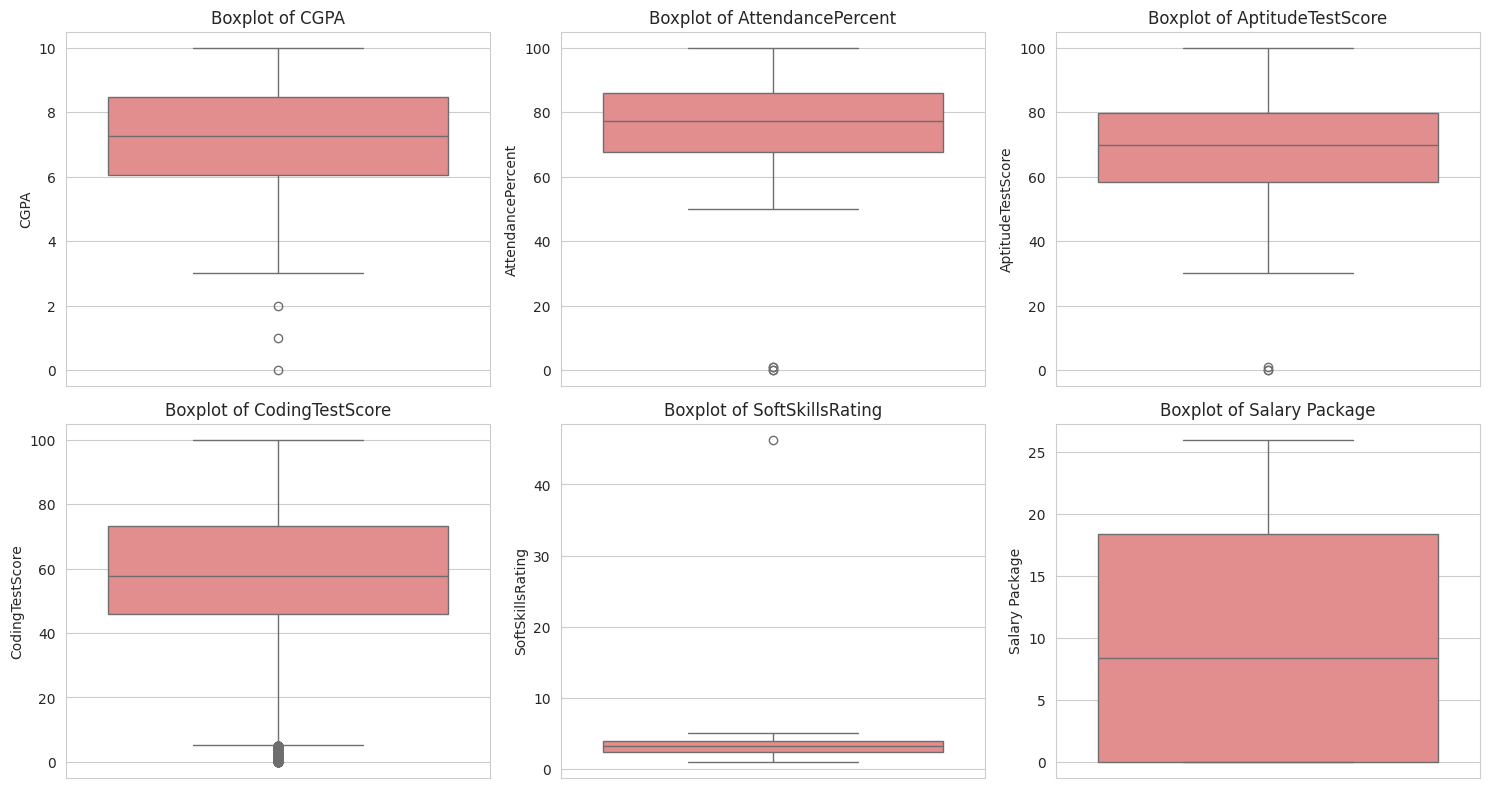

In [18]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [3]:
# Ensure all figure-generating cells (yuurSDzkhrRw, Iu3O2i49hvvo, qIoYjI0wh1g7, apeTfODxh6VR, 8q2nA-lTh-QP) are executed before this cell.
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Six Histograms
pdf.savefig(fig3)   # Page 3: Placement Rate by Stream
pdf.savefig(fig4)   # Page 4: Correlation Heatmap
pdf.savefig(fig5)   # Page 5: Boxplots

pdf.close()

print("\nEDA_Report.pdf created successfully with 5 pages!")

NameError: name 'fig1' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Load the dataset
df = pd.read_csv("placement_predict_50k Dataset.csv", on_bad_lines='skip')

# Define numerical columns for plots
num_cols = [
    'CGPA',
    'AttendancePercent',
    'AptitudeTestScore',
    'CodingTestScore',
    'SoftSkillsRating',
    'Salary Package',
]

# Ensure data types are numeric
df['CGPA'] = pd.to_numeric(df['CGPA'], errors='coerce')
df['SoftSkillsRating'] = pd.to_numeric(df['SoftSkillsRating'], errors='coerce')
df['Placed_Flag'] = df['PlacementStatus'].apply(
    lambda x: 1 if x == 'Placed' else 0
)

# Initialize PDF file
pdf = PdfPages('EDA_Report.pdf')

# --- Page 1: Missingness Heatmap ---
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missingness Heatmap - Placement Prediction Dataset')
plt.xlabel('Columns')
plt.tight_layout()
pdf.savefig(fig1)
plt.close(fig1)

# --- Page 2: Six Histograms ---
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
  row, colpos = divmod(i, 3)
  sns.histplot(
      df[col].dropna(), bins=30, kde=True, ax=axes2[row, colpos], color='steelblue'
  )
  axes2[row, colpos].set_title(f'Distribution of {col}')
plt.tight_layout()
pdf.savefig(fig2)
plt.close(fig2)

# --- Page 3: Placement Rate by Stream ---
fig3 = plt.figure(figsize=(10, 6))
placement_rate = (
    df.groupby('Stream')['Placed_Flag'].mean().sort_values(ascending=False)
    * 100
)
sns.barplot(
    x=placement_rate.index,
    y=placement_rate.values,
    hue=placement_rate.index,
    legend=False,
    palette='crest',
)
plt.title('Placement Rate (%) by Stream')
plt.xlabel('Stream')
plt.ylabel('Placement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
pdf.savefig(fig3)
plt.close(fig3)

# --- Page 4: Correlation Heatmap ---
fig4 = plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
pdf.savefig(fig4)
plt.close(fig4)

# --- Page 5: Boxplots ---
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
  row, colpos = divmod(i, 3)
  sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
  axes5[row, colpos].set_title(f'Boxplot of {col}')
plt.tight_layout()
pdf.savefig(fig5)
plt.close(fig5)

# Finalize and close PDF
pdf.close()
print('EDA_Report.pdf created successfully with 5 pages!')

/tmp/ipykernel_4828/2414384264.py:8: DtypeWarning: Columns (16,20,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("placement_predict_50k Dataset.csv", on_bad_lines='skip')


In [ ]:
files.download('EDA_Report.pdf')